In [1]:
import sys
from pathlib import Path
# Add parent directory to path to import from src/
sys.path.append(str(Path(__file__).parent.parent) if '__file__' in globals() else str(Path.cwd().parent))

from sionna.rt import (
    load_scene, RadioMapSolver, PathSolver, transform_mesh,
    MeshRadioMap, Receiver, subcarrier_frequencies
)
from src.utils import (
    extract_building_positions_from_scene, get_antenna_positions, get_scene_bounds,
    get_tx_color, get_building_bounds, clip_terrain_to_buildings, visualize_time_frequency_response,
    display_path_count_histogram, visualize_antenna_frequency_response
)
from src.radio_map import filter_positions_by_edge_distance
from src.base_station import set_tx_antenna_array, add_base_station
from src.user_equipment import set_rx_antenna_array, generate_ue_parameters
from src.path_solver import get_doppler_stats, get_delay_stats, get_num_paths_histogram, get_valid_rx_mask
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalize_channels(
    channels: np.ndarray,
    *,
    per_sample: bool = False,
    eps: float = 1e-30,
) -> np.ndarray:
    """
    Normalize complex channels by power normalization.

    Divides each channel coefficient by sqrt(mean power), so that
    the normalized channel has unit mean power: E[|H_norm|^2] = 1.

    Args:
        channels:   Complex array of any shape, where axis 0 is the sample axis.
        per_sample: If True, normalize each sample by its own power (removes path loss,
                    isolates small-scale fading structure).
                    If False, normalize by global mean power across the entire array.
        eps:        Small constant to avoid division by zero.

    Returns:
        Power-normalized complex array of same shape, dtype complex64.
    """
    h = np.asarray(channels)

    if not np.iscomplexobj(h):
        raise ValueError(f"`channels` must be complex; got dtype={h.dtype}")

    if per_sample:
        sample_axes = tuple(range(1, h.ndim))
        mean_power = np.mean(np.abs(h) ** 2, axis=sample_axes, keepdims=True)

        clipped = mean_power < eps
        if np.any(clipped):
            n_clipped = int(np.sum(clipped))
            warnings.warn(
                f"{n_clipped} sample(s) have mean_power < eps={eps:.3e}; "
                "eps will be used as the denominator for those samples. "
                "Check for zero or near-zero channels.",
                RuntimeWarning,
                stacklevel=2,
            )
    else:
        mean_power = np.mean(np.abs(h) ** 2)

        if mean_power < eps:
            warnings.warn(
                f"Global mean_power={mean_power:.3e} < eps={eps:.3e}; "
                "eps will be used as the denominator. "
                "Check for zero or near-zero channels.",
                RuntimeWarning,
                stacklevel=2,
            )

    mean_power = np.maximum(mean_power, eps)
    h_norm = h / np.sqrt(mean_power)

    return h_norm.astype(np.complex64, copy=False)

In [6]:
city = "boston_1"
scene_dir = Path(f"../scenes/{city}/")  # path to the scene directory
scene_xml_path = scene_dir / "scene.xml"  # path to the scene XML file
dataset_name = "TemporalWiMAEv4"

data_dir = Path(f"/opt/shared/datasets/CSIGen/{dataset_name}/{city}/20260302_121714")
npz_files = list(data_dir.glob("*.npz"))
npz_files.sort()

BS_IDX = 0  # from 0 to 5
SECTOR_IDX = 0  # from 0 to 5
file_idx = BS_IDX * 6 + SECTOR_IDX # from 0 to 35

npz_file = npz_files[file_idx]
print(f"Loading file {npz_file.name}")


Loading file channel_tx_0.npz


In [7]:
with np.load(npz_file, allow_pickle=True) as data:
    print("The shape of the data is ", data["h"].shape)

    # Read metadata and antenna geometry
    meta = data["metadata"].item()
    cfg = meta["config"]

    # Antenna array geometry (must be present in metadata)
    if "tx_num_rows" not in cfg or "tx_num_cols" not in cfg:
        raise RuntimeError(
            "Antenna geometry not found in metadata config "
            "(expected 'tx_num_rows' and 'tx_num_cols')."
        )

    # Subcarrier spacing from config is stored in Hz
    if "subcarrier_spacing" not in cfg:
        raise RuntimeError("Expected 'subcarrier_spacing' in metadata config.")

    n_rows = int(cfg["tx_num_rows"])
    n_cols = int(cfg["tx_num_cols"])
    subcarrier_spacing_hz = float(cfg["subcarrier_spacing"])
    subcarrier_spacing_khz = subcarrier_spacing_hz / 1e3

    print(f"Antenna array geometry: {n_rows}x{n_cols}")
    print(f"Subcarrier spacing: {subcarrier_spacing_khz} kHz")

    tx_name = meta.get("tx_name")
    if tx_name is None:
        raise RuntimeError("Expected 'tx_name' in metadata.")

    base_name = f"{dataset_name}_{city}_{tx_name}"

    # Get rid of singleton axes (e.g. (N, 1, 1, ...)) so that
    # the first axis is samples/users and the rest are channel dimensions.
    h = np.squeeze(data["h"])

print("Squeezed data shape: ", h.shape)
print(
    "Loaded ",
    h.shape[0],
    " channels",
    "with shape ",
    h.shape[1:],
)

The shape of the data is  (4668, 1, 1, 32, 14, 32)
Antenna array geometry: 4x8
Subcarrier spacing: 30.0 kHz
Squeezed data shape:  (4668, 32, 14, 32)
Loaded  4668  channels with shape  (32, 14, 32)


In [8]:
print(f"There are {meta['los_binary'].sum()/meta['los_binary'].size*100:.1f}% LOS samples")

There are 34.2% LOS samples


In [9]:
# channels = normalize_channels(h)
channels = h

In [10]:
scene = load_scene(scene_xml_path, merge_shapes=False) 
bs_name = f"BS_{BS_IDX}_sector_{SECTOR_IDX}"

tx_position = meta.get("tx_position")
rx_positions = meta.get("rx_positions")
los_indices = np.where(meta['los_binary'] == 1)[0]
nlos_indices = np.where(meta['los_binary'] == 0)[0]

2026-03-09 00:17:12 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).


In [11]:
set_tx_antenna_array(
    scene,
    num_rows=4,
    num_cols=8,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V")

# For radio map solver, receive antenna array params are assumed fixed
# and modifying them does not matter. See below from the Sionna RT technical report:
# The receive antenna pattern is not applied here. Instead, the squared norm of the
# electric field is used. This is equivalent to assuming that a receiver positioned
# on the measurement plane uses a dual-polarized isotropic antenna, and that both components are combined non-coherently.
# Therefore, the following line is needed for Path Solver not Radio Map Solver
set_rx_antenna_array(
    scene,
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V"
)

print("Adding base station at ", tx_position)
add_base_station(
        scene,
        bs_name,
        position=list(tx_position),
        num_sectors=6,
        mechanical_tilt=10,
        azimuth_offset=0,
        tx_power_dbm=43,
        display_radius=15
    )

# add los receivers
for user_idx in los_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 0, 1]
    )
    scene.add(rx)

# nlos receivers
for user_idx in nlos_indices:
    rx = Receiver(
        name=f"UE_{user_idx}",
        position=list(rx_positions[user_idx]),
        display_radius=20,
        color=[0, 1, 0]
    )
    scene.add(rx)


print(f"Added {len(los_indices)} receivers to scene")


Adding base station at  [[-55.303642]
 [-73.8676  ]
 [220.5     ]]
Added 1597 receivers to scene


In [ ]:
scene.preview()

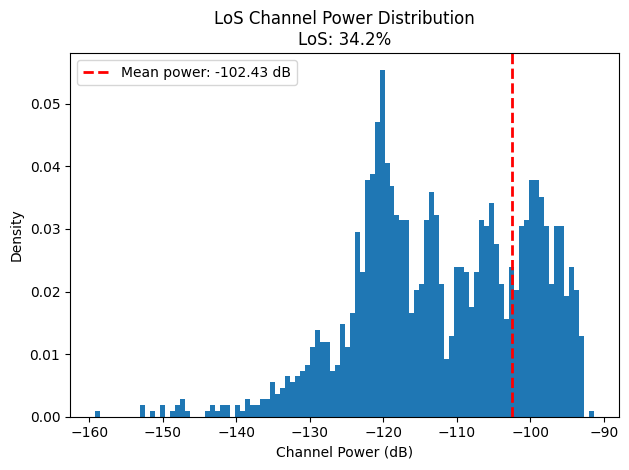

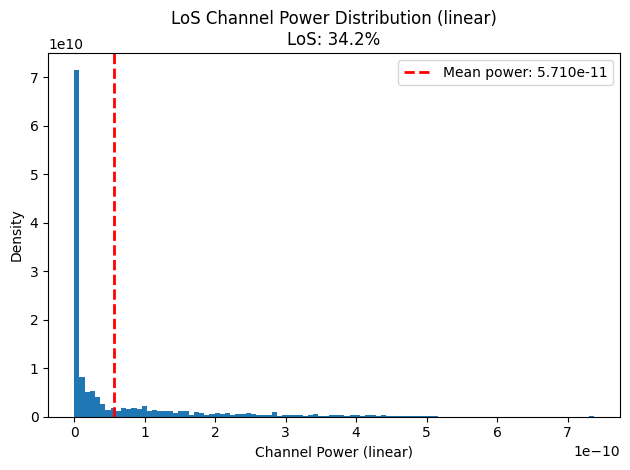

In [12]:
los_sampled_channels = channels[los_indices]
los_channel_power = np.mean(np.abs(los_sampled_channels) ** 2, axis=(1, 2, 3))
los_channel_power_db = 10 * np.log10(los_channel_power)
los_mean_linear_power = los_channel_power.mean()
los_mean_power_db = 10 * np.log10(los_mean_linear_power)

# Percentage of LoS / nLoS samples
los_percentage = meta["los_binary"].sum() / meta["los_binary"].size * 100
nlos_percentage = 100 - los_percentage

plt.hist(los_channel_power_db, bins=100, density=True)
plt.xlabel("Channel Power (dB)")
plt.ylabel("Density")
plt.title(f"LoS Channel Power Distribution\nLoS: {los_percentage:.1f}%")
plt.axvline(
    los_mean_power_db,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {los_mean_power_db:.2f} dB",
)
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(los_channel_power, bins=100, density=True)
plt.xlabel("Channel Power (linear)")
plt.ylabel("Density")
plt.title(f"LoS Channel Power Distribution (linear)\nLoS: {los_percentage:.1f}%")
plt.axvline(
    los_mean_linear_power,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {los_mean_linear_power:.3e}",
)
plt.legend()
plt.tight_layout()
plt.show()


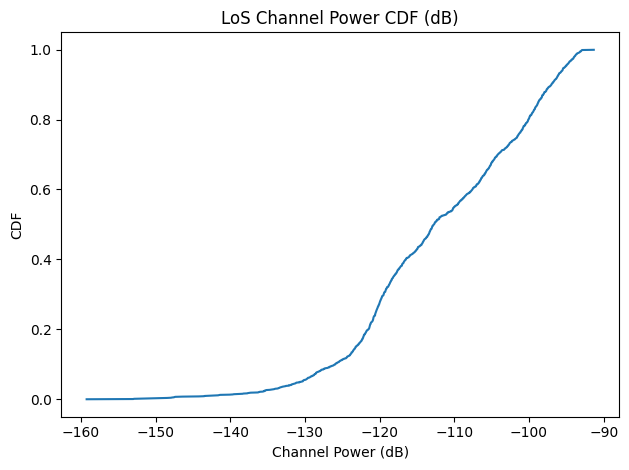

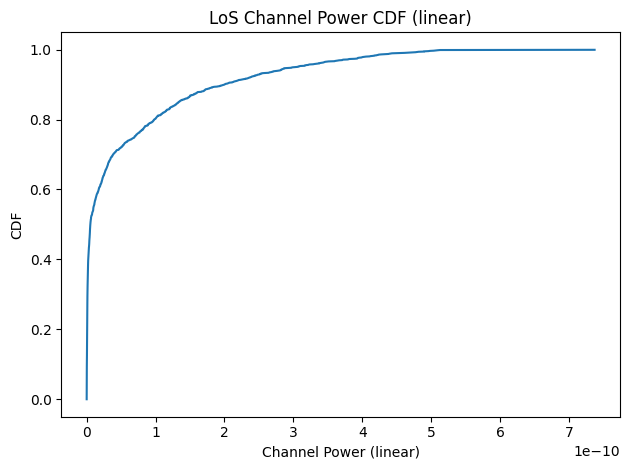

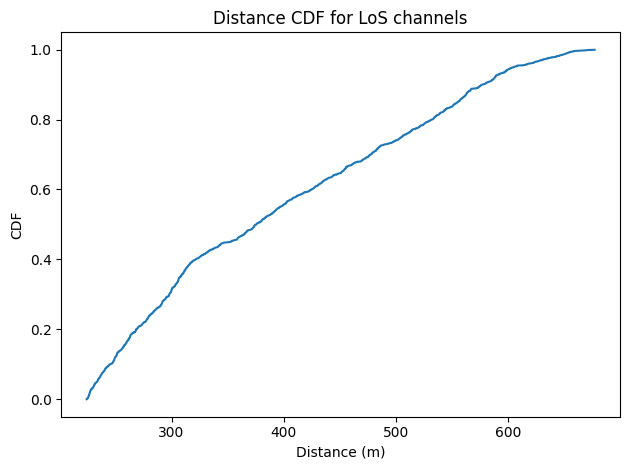

In [13]:
# LoS: CDFs
plt.plot(
    np.sort(los_channel_power_db),
    np.arange(len(los_channel_power_db)) / len(los_channel_power_db),
)
plt.xlabel("Channel Power (dB)")
plt.ylabel("CDF")
plt.title("LoS Channel Power CDF (dB)")
plt.tight_layout()
plt.show()

plt.plot(
    np.sort(los_channel_power),
    np.arange(len(los_channel_power)) / len(los_channel_power),
)
plt.xlabel("Channel Power (linear)")
plt.ylabel("CDF")
plt.title("LoS Channel Power CDF (linear)")
plt.tight_layout()
plt.show()

# LoS: distance CDF (use LoS-only RX positions)
los_rx_positions = rx_positions[los_indices]
los_channel_distances = np.linalg.norm(los_rx_positions - tx_position, axis=(1, 2))
los_distance_cdf_x = np.sort(los_channel_distances)
plt.plot(los_distance_cdf_x, np.arange(len(los_distance_cdf_x)) / len(los_distance_cdf_x))
plt.xlabel("Distance (m)")
plt.ylabel("CDF")
plt.title("Distance CDF for LoS channels")
plt.tight_layout()
plt.show()

Mean linear power of nLoS channels:  5.0713204e-13


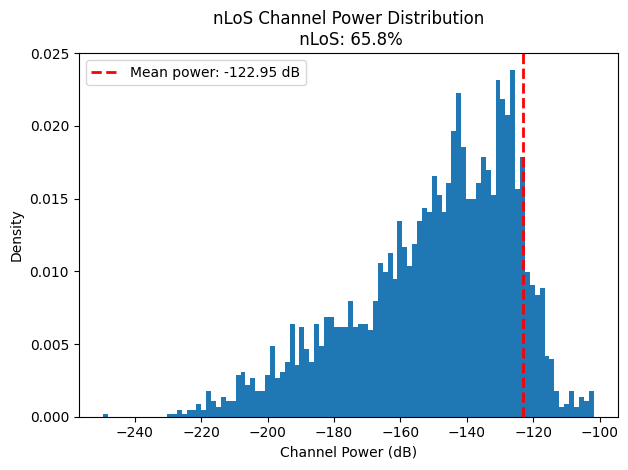

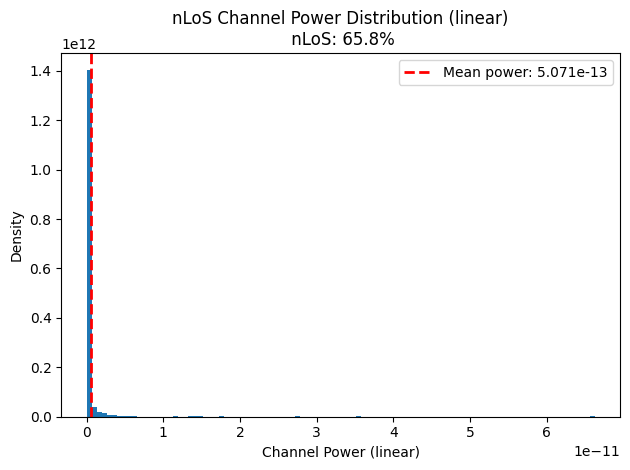

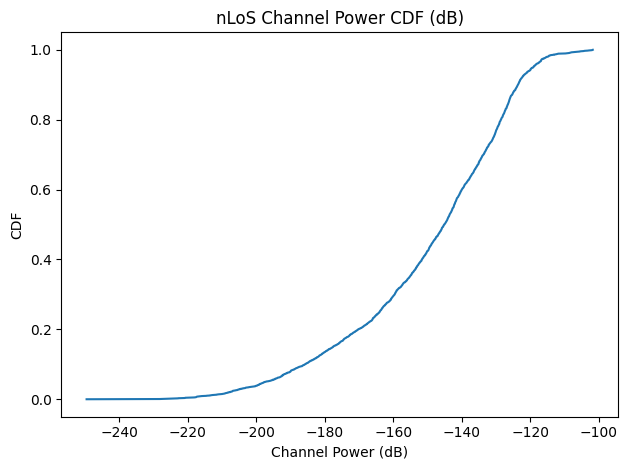

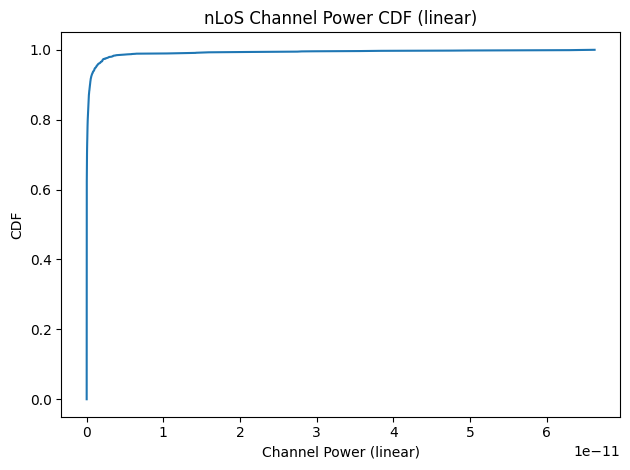

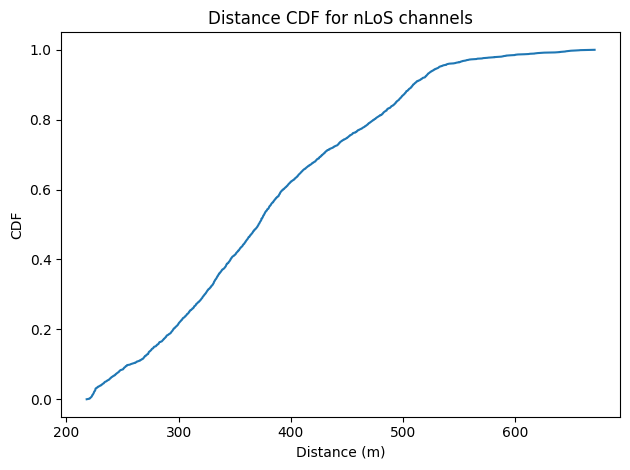

In [14]:
nlos_sampled_channels = channels[nlos_indices]
nlos_channel_power = np.mean(np.abs(nlos_sampled_channels) ** 2, axis=(1, 2, 3))
nlos_channel_power_db = 10 * np.log10(nlos_channel_power)
nlos_mean_linear_power = nlos_channel_power.mean()
nlos_mean_power_db = 10 * np.log10(nlos_mean_linear_power)
print("Mean linear power of nLoS channels: ", nlos_mean_linear_power)

# Percentage of LoS / nLoS samples
los_percentage = meta["los_binary"].sum() / meta["los_binary"].size * 100
nlos_percentage = 100 - los_percentage

# nLoS: histograms
plt.hist(nlos_channel_power_db, bins=100, density=True)
plt.xlabel("Channel Power (dB)")
plt.ylabel("Density")
plt.title(f"nLoS Channel Power Distribution\n nLoS: {nlos_percentage:.1f}%")
plt.axvline(
    nlos_mean_power_db,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {nlos_mean_power_db:.2f} dB",
)
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(nlos_channel_power, bins=100, density=True)
plt.xlabel("Channel Power (linear)")
plt.ylabel("Density")
plt.title(f"nLoS Channel Power Distribution (linear)\n nLoS: {nlos_percentage:.1f}%")
plt.axvline(
    nlos_mean_linear_power,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean power: {nlos_mean_linear_power:.3e}",
)
plt.legend()
plt.tight_layout()
plt.show()

# nLoS: CDFs
plt.plot(
    np.sort(nlos_channel_power_db),
    np.arange(len(nlos_channel_power_db)) / len(nlos_channel_power_db),
)
plt.xlabel("Channel Power (dB)")
plt.ylabel("CDF")
plt.title("nLoS Channel Power CDF (dB)")
plt.tight_layout()
plt.show()

plt.plot(
    np.sort(nlos_channel_power),
    np.arange(len(nlos_channel_power)) / len(nlos_channel_power),
)
plt.xlabel("Channel Power (linear)")
plt.ylabel("CDF")
plt.title("nLoS Channel Power CDF (linear)")
plt.tight_layout()
plt.show()

# nLoS: distance CDF (use nLoS-only RX positions)
nlos_rx_positions = rx_positions[nlos_indices]
nlos_channel_distances = np.linalg.norm(nlos_rx_positions - tx_position, axis=(1, 2))
nlos_distance_cdf_x = np.sort(nlos_channel_distances)
plt.plot(nlos_distance_cdf_x, np.arange(len(nlos_distance_cdf_x)) / len(nlos_distance_cdf_x))
plt.xlabel("Distance (m)")
plt.ylabel("CDF")
plt.title("Distance CDF for nLoS channels")
plt.tight_layout()
plt.show()